## Carga de datos y librerías

In [ ]:
import pandas as pd   # para manejar DataFrames
import numpy as np  # para operaciones numéricas
import matplotlib.pyplot as plt # para hacer gráficas

In [ ]:
# Cargamos la tabla "Características y composición del hogar" de la ECV 2025
df=pd.read_excel("../data/processed/Características y composición del hogar.xlsx")

In [ ]:
### Eliminacmos duplicados - Revisamos si hay filas exactamente iguales y las eliminamos. No se encontró ningún duplicado.
df.drop_duplicates()

## 2. Preparación de los datos (ETL)

### Selección de variables
Creamos un DataFrame solo con las variables que necesitamos:
- **P6040**: edad (numérica discreta)
- **P756**: lugar de nacimiento (categórica nominal)
- **P756S1, P756S2, P756S3**: departamento, municipio y país de nacimiento (categóricas nominales)
- **P1895, P1896, P1897, P1898, P1899, P3175**: satisfacción con la vida, el ingreso, la salud, la seguridad, el trabajo y el tiempo libre (escala de 0 a 10)

In [ ]:
# Nuevo DataFrame solo con las columnas que vamos a usar en el análisis
df_variables=df[["P6040","P756","P756S1","P756S2","P756S3","P1895","P1896","P1897","P1898","P1899","P3175"]]
df_variables 

,P6040,P756,P756S1,P756S2,P756S3,P1895,P1896,P1897,P1898,P1899,P3175
0,45,1,NaN,NaN,NaN,8.0,99.0,10.0,10.0,5.0,7.0
1,25,1,NaN,NaN,NaN,10.0,8.0,10.0,10.0,8.0,7.0
2,16,1,NaN,NaN,NaN,10.0,99.0,10.0,10.0,10.0,10.0
3,10,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,62,2,13.0,13433.0,NaN,5.0,4.0,7.0,7.0,4.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...
235345,31,1,NaN,NaN,NaN,10.0,10.0,10.0,10.0,10.0,10.0
235346,8,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
235347,31,1,NaN,NaN,NaN,10.0,10.0,10.0,10.0,9.0,9.0
235348,32,1,NaN,NaN,NaN,10.0,10.0,9.0,10.0,10.0,9.0


### Filtro de edad
Filtramos con la variable P6040 (edad) para quedarnos solo con las personas de **18 años o más**..

In [ ]:
# query filtra las filas que cumplen la condición: edad mayor o igual a 18
df_variables_filtrado=df_variables.query("P6040>=18")

### Calidad de los datos: valores nulos
Calculamos el porcentaje de valores nulos de cada variable frente al total de registros.

In [ ]:
# isna() marca los nulos, mean() saca la proporción, *100 la pasa a porcentaje
# sort_values ordena de mayor a menor porcentaje de nulos
(df_variables_filtrado.isna().mean()*100).sort_values(ascending=False)

P756S3    96.923122
P756S2    63.720389
P756S1    63.720389
P756       0.000000
P6040      0.000000
P1895      0.000000
P1896      0.000000
P1897      0.000000
P1898      0.000000
P1899      0.000000
P3175      0.000000
dtype: float64

### Tratamiento de nulos: "No aplica"
Solo P756S1, P756S2 y P756S3 tienen nulos. No son datos perdidos, sino preguntas que no le correspondían a la persona:
- Si nació **en este municipio** (P756 = 1), no responde departamento, municipio ni país.
- Si nació **en otro municipio** (P756 = 2), no responde país.
- Si nació **en otro país** (P756 = 3), no responde departamento ni municipio.

Por eso reemplazamos esos nulos por "No aplica".

Cambiamos el tipo de la columna a *object* para que pueda guardar texto.

In [ ]:
# Convertimos la columna a tipo object (texto) para poder escribir "No aplica"
df_variables_filtrado["P1896"] = df_variables_filtrado["P1896"].astype("object")

In [ ]:
# Función que revisa cada fila y pone "No aplica" en los nulos según el valor de P756
def corregir_no_aplica(fila):

    # Caso 1: nació en este municipio -> no aplican departamento, municipio ni país
    if fila["P756"] == 1:

        if pd.isna(fila["P756S1"]):
            fila["P756S1"] = "No aplica"

        if pd.isna(fila["P756S2"]):
            fila["P756S2"] = "No aplica"

        if pd.isna(fila["P756S3"]):
            fila["P756S3"] = "No aplica"

    # Caso 2: nació en otro municipio -> solo no aplica el país
    elif fila["P756"] == 2:

        if pd.isna(fila["P756S3"]):
            fila["P756S3"] = "No aplica"

    # Caso 3: nació en otro país -> no aplican departamento ni municipio
    elif fila["P756"] == 3:

        if pd.isna(fila["P756S1"]):
            fila["P756S1"] = "No aplica"

        if pd.isna(fila["P756S2"]):
            fila["P756S2"] = "No aplica"
            
    # Devuelve la fila ya corregida
    return fila

Aplicamos la función a cada fila del DataFrame filtrado.

In [ ]:
# apply con axis=1 ejecuta la función fila por fila
df_variables_filtrado=df_variables_filtrado.apply(corregir_no_aplica, axis=1)

Verificamos que ya no queden valores nulos.

In [ ]:
# Volvemos a calcular el porcentaje de nulos: todas las variables deben quedar en 0 %
(df_variables_filtrado.isna().mean()*100).sort_values(ascending=False)

P6040     0.0
P756      0.0
P756S1    0.0
P756S2    0.0
P756S3    0.0
P1895     0.0
P1896     0.0
P1897     0.0
P1898     0.0
P1899     0.0
P3175     0.0
dtype: float64

## 3. Análisis descriptivo

In [ ]:
# Revisamos los nombres de las columnas con las que vamos a trabajar
df_variables_filtrado.columns 

### Edad (P6040)

La variable  **P6040 - ¿Cuántos años cumplidos tiene?** es una variable de tipo numérico discreto que cuenta con una media de 45.84, una mediana de 44, un valor maximo de 108 y un valor minimo de 18. 

In [ ]:
# Resumen estadístico: conteo, media, desviación, mínimo, cuartiles y máximo
df_variables_filtrado["P6040"].describe()

count    172025.000000
mean         45.844046
std          17.972662
min          18.000000
25%          31.000000
50%          44.000000
75%          60.000000
max         108.000000
Name: P6040, dtype: float64

In [ ]:
# Mediana de la edad
df_variables_filtrado["P6040"].median()

In [ ]:
# Moda: la edad que más se repite
df_variables_filtrado["P6040"].mode()

0    30
Name: P6040, dtype: int64

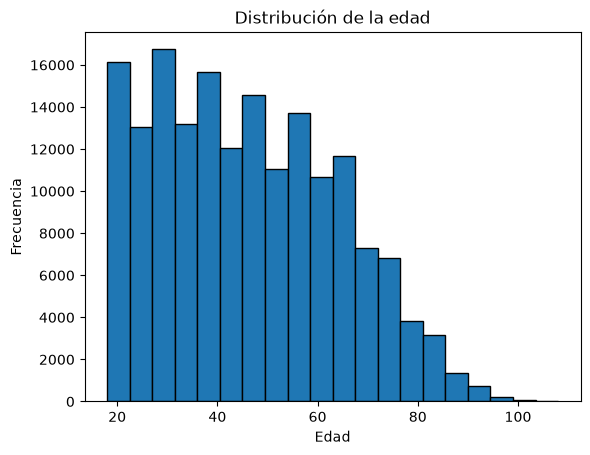

In [ ]:
# Histograma para ver cómo se distribuyen las edades
df_variables_filtrado["P6040"].plot.hist(bins=20, edgecolor="black")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Distribución de la edad")
plt.show()

### Satisfacción con la vida (P1895)

La variable **P1895 - En general, ¿qué tan satisfecho/a se siente con su vida actualmente?** es una variable de tipo numérico discreto que cuenta con una media de 7, una mediana de 7, un valor maximo de 10 y un valor minimo de 0. 


In [ ]:
# Resumen estadístico de la variable
df_variables_filtrado["P1895"].describe()

In [ ]:
# Mediana de la variable
df_variables_filtrado["P1895"].median()

np.float64(8.0)

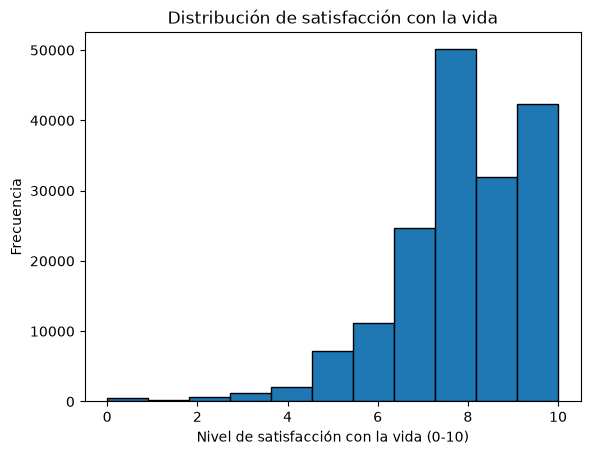

In [ ]:
# Histograma con 11 barras, una por cada valor de la escala de 0 a 10
df_variables_filtrado["P1895"].plot.hist(bins=11, edgecolor="black")
plt.xlabel("Nivel de satisfacción con la vida (0-10)")
plt.ylabel("Frecuencia")
plt.title("Distribución de satisfacción con la vida")
plt.show()

### Satisfacción con el ingreso (P1896)

La variable **P1896 - En general, ¿qué tan satisfecho/a se siente con su ingreso actualmente?** es una variable de tipo numérico discreto que cuenta con una media de 7, una mediana de 7, un valor maximo de 10 y un valor minimo de 0. 


In [ ]:
# Frecuencia de cada respuesta: aquí aparece el valor 99, que está fuera de la escala 0-10
df_variables_filtrado["P1896"].unique()
df_variables_filtrado["P1896"].value_counts()

P1896
8.0     30799
7.0     25626
99.0    21681
6.0     19081
10.0    17703
5.0     17386
9.0     14440
4.0      8694
3.0      7044
2.0      4521
0.0      2687
1.0      2363
Name: count, dtype: int64

**Tratamiento del valor 99:** la escala es de 0 a 10, pero 21.681 personas (≈12,6 %) tienen el valor 99, que no corresponde a ninguna respuesta del diccionario de datos. Lo reemplazamos por la mediana (7) porque la mediana no se ve afectada por valores extremos y así no perdemos a esas personas.

In [ ]:
 Reemplazamos los 99 por 7, que es la mediana de la variable
df_variables_filtrado["P1896"] = df_variables_filtrado["P1896"].replace(99.0, 7.0)

In [ ]:
# Verificamos que ya no quede ningún 99
df_variables_filtrado["P1896"].unique()

array([ 7.,  8.,  4.,  9.,  1.,  0.,  5.,  3., 10.,  6.,  2.])

In [82]:
df_variables_filtrado["P1896"].describe()

count    172025.000000
mean          6.704026
std           2.212583
min           0.000000
25%           6.000000
50%           7.000000
75%           8.000000
max          10.000000
Name: P1896, dtype: float64

In [83]:
df_variables_filtrado["P1896"].median()

np.float64(7.0)

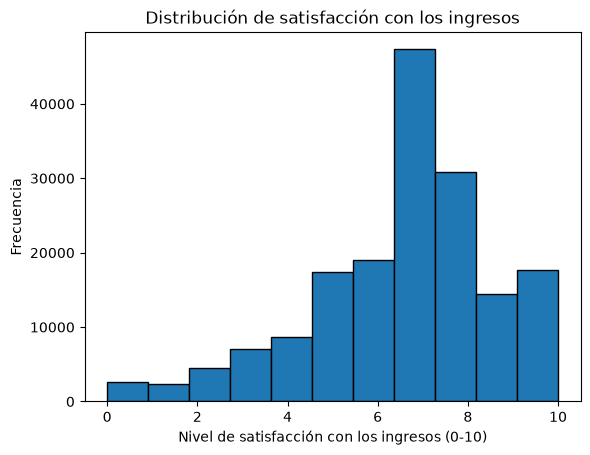

In [84]:
df_variables_filtrado["P1896"].plot.hist(bins=11, edgecolor="black")
plt.xlabel("Nivel de satisfacción con los ingresos (0-10)")
plt.ylabel("Frecuencia")
plt.title("Distribución de satisfacción con los ingresos")
plt.show()

La variable **P1897 - En general, ¿qué tan satisfecho/a se siente con su salud actualmente?** es una variable de tipo numérico discreto que cuenta con una media de 7.83, una mediana de 8, un valor maximo de 10 y un valor minimo de 0. 

In [85]:
df_variables_filtrado["P1897"].describe()

count    172025.000000
mean          7.839128
std           1.873769
min           0.000000
25%           7.000000
50%           8.000000
75%           9.000000
max          10.000000
Name: P1897, dtype: float64

In [86]:
df_variables_filtrado["P1897"].median()

np.float64(8.0)

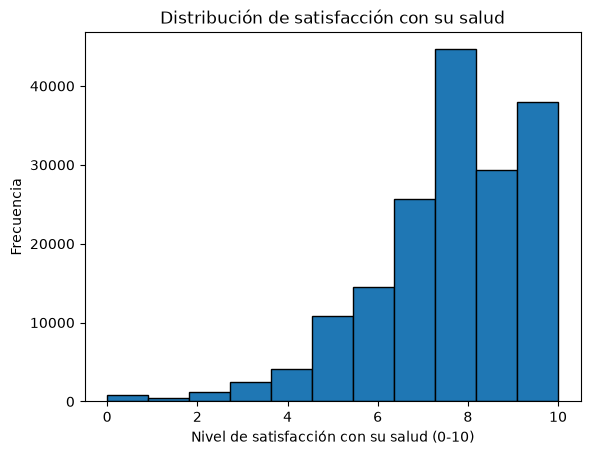

In [87]:
df_variables_filtrado["P1897"].plot.hist(bins=11, edgecolor="black")
plt.xlabel("Nivel de satisfacción con su salud (0-10)")
plt.ylabel("Frecuencia")
plt.title("Distribución de satisfacción con su salud")
plt.show()

La variable **P1898 - En general, ¿qué tan satisfecho/a se siente con su nivel de seguridad actualmente?** es una variable de tipo numérico discreto que cuenta con una media de 7.75, una mediana de 8, un valor maximo de 10 y un valor minimo de 0. 

In [88]:
df_variables_filtrado["P1898"].describe()

count    172025.000000
mean          7.759564
std           1.948263
min           0.000000
25%           7.000000
50%           8.000000
75%           9.000000
max          10.000000
Name: P1898, dtype: float64

In [89]:
df_variables_filtrado["P1898"].median()

np.float64(8.0)

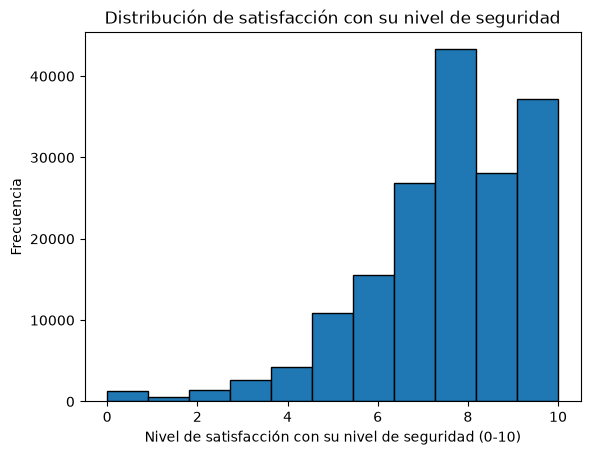

In [90]:
df_variables_filtrado["P1898"].plot.hist(bins=11, edgecolor="black")
plt.xlabel("Nivel de satisfacción con su nivel de seguridad (0-10)")
plt.ylabel("Frecuencia")
plt.title("Distribución de satisfacción con su nivel de seguridad")
plt.show()

La variable **P1899 - En general, ¿qué tan satisfecho/a se siente con su trabajo/actividad actualmente?** es una variable de tipo numérico discreto que cuenta con una media de 7.35, una mediana de 8, un valor maximo de 10 y un valor minimo de 0. 

In [91]:
df_variables_filtrado["P1899"].describe()

count    172025.000000
mean          7.354739
std           2.201839
min           0.000000
25%           6.000000
50%           8.000000
75%           9.000000
max          10.000000
Name: P1899, dtype: float64

In [92]:
df_variables_filtrado["P1899"].median()

np.float64(8.0)

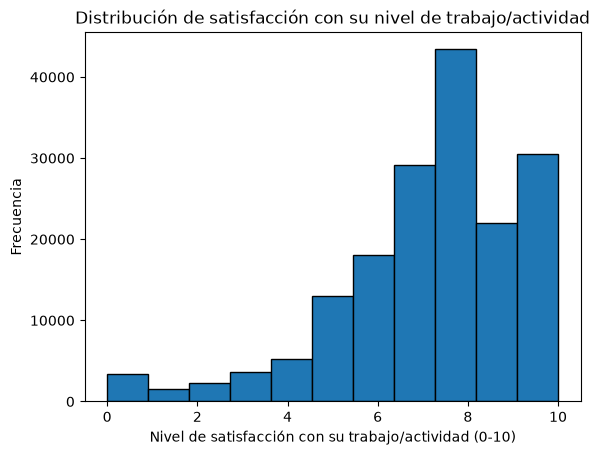

In [93]:
df_variables_filtrado["P1899"].plot.hist(bins=11, edgecolor="black")
plt.xlabel("Nivel de satisfacción con su trabajo/actividad (0-10)")
plt.ylabel("Frecuencia")
plt.title("Distribución de satisfacción con su nivel de trabajo/actividad")
plt.show()

La variable **P3175 - En general, ¿qué tan satisfecho/a se siente con su tiempo libre?** es una variable de tipo numérico discreto que cuenta con una media de 7.58, una mediana de 8, un valor maximo de 10 y un valor minimo de 0. 

In [94]:
df_variables_filtrado["P3175"].describe()

count    172025.000000
mean          7.585781
std           1.909613
min           0.000000
25%           7.000000
50%           8.000000
75%           9.000000
max          10.000000
Name: P3175, dtype: float64

In [95]:
df_variables_filtrado["P3175"].median()

np.float64(8.0)

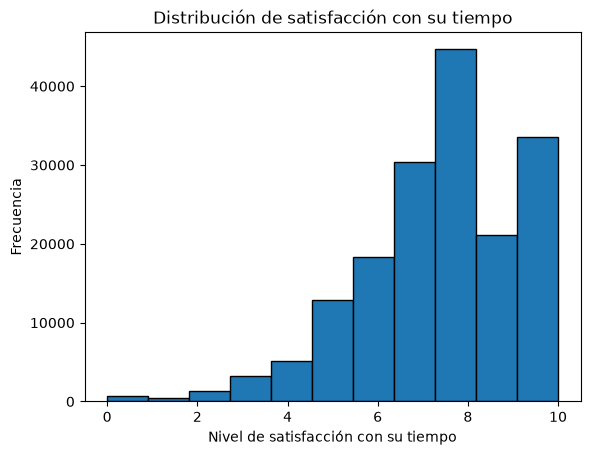

In [96]:
df_variables_filtrado["P3175"].plot.hist(bins=11, edgecolor="black")
plt.xlabel("Nivel de satisfacción con su tiempo")
plt.ylabel("Frecuencia")
plt.title("Distribución de satisfacción con su tiempo")
plt.show()

La variable **P756 - ¿Dónde nació?** es una variable de tipo categorica nominal que cuenta con unas frecuencias de: 

* 1 es si nacio en este municipio y tiene una frecuencia de 104322.
* 2 es si nacio afuera del municipio y tiene una frecuencia de 62410.
* 3 es si son de otro pais y tiene una frecuencia de 5293.

In [97]:
df_variables_filtrado["P756"].unique()

array([1, 2, 3])

In [98]:
df_variables_filtrado["P756"].value_counts()

P756
1    104322
2     62410
3      5293
Name: count, dtype: int64

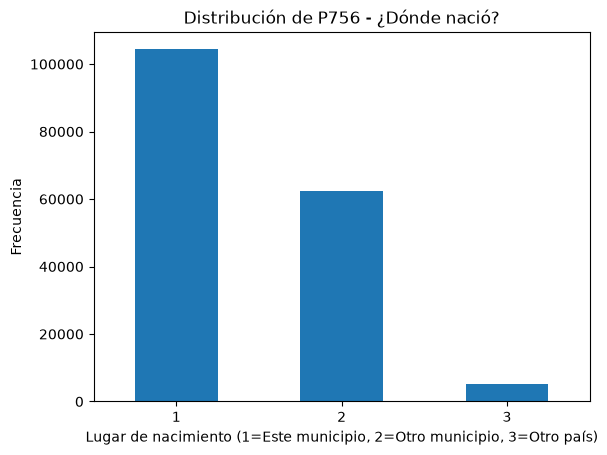

In [99]:
df_variables_filtrado["P756"].value_counts().plot.bar()
plt.xlabel("Lugar de nacimiento (1=Este municipio, 2=Otro municipio, 3=Otro país)")
plt.ylabel("Frecuencia")
plt.title("Distribución de P756 - ¿Dónde nació?")
plt.xticks(rotation=0)
plt.show()

La variable **P756S1 - Departamento** es una variable de tipo categorica nominal y estan afuera de bogota. 

In [100]:
df_variables_filtrado["P756S1"].unique()

array(['No aplica', 13.0, 8.0, 23.0, 70.0, 11.0, 76.0, 66.0, 25.0, 52.0,
       86.0, 41.0, 19.0, 68.0, 17.0, 73.0, 5.0, 15.0, 27.0, 47.0, 44.0,
       18.0, 50.0, 94.0, 97.0, 91.0, 81.0, 99.0, 63.0, 95.0, 85.0, 54.0,
       20.0, 88.0], dtype=object)

In [101]:
df_variables_filtrado["P756S1"].value_counts()

P756S1
No aplica    109615
5.0            4897
15.0           3958
76.0           3879
68.0           3454
11.0           3265
73.0           3199
25.0           3083
17.0           2930
50.0           2449
52.0           2396
19.0           2328
41.0           2304
54.0           2238
18.0           2163
13.0           2002
47.0           1905
8.0            1774
23.0           1647
63.0           1624
66.0           1584
20.0           1556
70.0           1433
85.0           1190
86.0           1055
27.0           1006
44.0            871
81.0            705
99.0            397
95.0            367
97.0            289
91.0            230
94.0            218
88.0             14
Name: count, dtype: int64

La variable **P756S2 - Municipio y P756S3 - En otro país** es una variable de tipo categorica nominal y estan afuera de bogota y son de otro pais . 

In [102]:
df_variables_filtrado["P756S2"].unique()

array(['No aplica', 13433.0, 13052.0, ..., 25898.0, 94887.0, 23682.0],
      shape=(1119,), dtype=object)

In [103]:
df_variables_filtrado["P756S2"].value_counts()

P756S2
No aplica    109615
11001.0        3265
8001.0         1005
5001.0          931
76001.0         929
              ...  
15696.0           2
68132.0           2
25368.0           1
97777.0           1
25898.0           1
Name: count, Length: 1119, dtype: int64

### Correlacion 

In [104]:
df_variables_filtrado[["P6040", "P1895"]].corr()

,P6040,P1895
P6040,1.00000,-0.06375
P1895,-0.06375,1.00000


In [105]:
df_variables_filtrado[["P6040", "P1895"]].corr(method="spearman")

,P6040,P1895
P6040,1.000000,-0.050822
P1895,-0.050822,1.000000


### Valores atipicos

In [106]:
z=(df_variables_filtrado["P6040"]-df_variables_filtrado["P6040"].mean())/df_variables_filtrado["P6040"].std()
z


0        -0.046963
1        -1.159764
4         0.898918
5        -0.436443
6         0.175597
            ...   
235344   -0.770284
235345   -0.825924
235347   -0.825924
235348   -0.770284
235349   -0.046963
Name: P6040, Length: 172025, dtype: float64

In [107]:
df_variables_filtrado.assign(valores_atipicos_edad= z).query("valores_atipicos_edad >= 3")

,P6040,P756,P756S1,P756S2,P756S3,P1895,P1896,P1897,P1898,P1899,P3175,valores_atipicos_edad
474,103,2,25.0,25862.0,No aplica,10.0,7.0,5.0,10.0,5.0,5.0,3.180161
38673,103,2,76.0,76246.0,No aplica,7.0,7.0,7.0,7.0,8.0,7.0,3.180161
47234,100,1,No aplica,No aplica,No aplica,2.0,7.0,5.0,3.0,0.0,6.0,3.013241
49453,105,1,No aplica,No aplica,No aplica,3.0,6.0,4.0,8.0,3.0,7.0,3.291441
61584,104,2,73.0,73001.0,No aplica,9.0,7.0,7.0,8.0,8.0,8.0,3.235801
80413,103,2,13.0,13001.0,No aplica,4.0,6.0,4.0,4.0,4.0,4.0,3.180161
92082,100,2,66.0,66440.0,No aplica,5.0,7.0,5.0,10.0,4.0,10.0,3.013241
92940,100,2,70.0,70670.0,No aplica,8.0,8.0,9.0,8.0,8.0,8.0,3.013241
98955,101,1,No aplica,No aplica,No aplica,5.0,5.0,5.0,5.0,5.0,5.0,3.068881
109033,100,1,No aplica,No aplica,No aplica,7.0,7.0,8.0,8.0,8.0,6.0,3.013241


<Axes: >

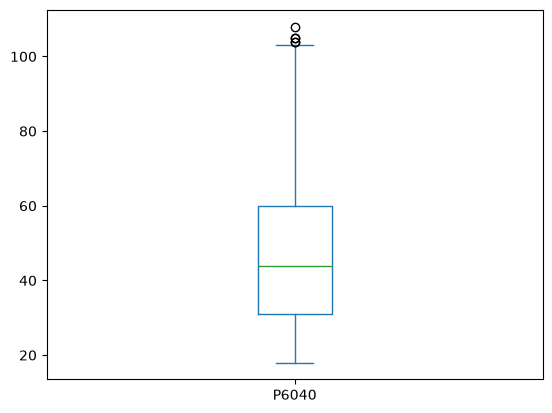

In [108]:
df_variables_filtrado["P6040"].plot.box()

In [109]:
df_variables_filtrado = df_variables_filtrado.query("P6040 < 100")
df_variables_filtrado

,P6040,P756,P756S1,P756S2,P756S3,P1895,P1896,P1897,P1898,P1899,P3175
0,45,1,No aplica,No aplica,No aplica,8.0,7.0,10.0,10.0,5.0,7.0
1,25,1,No aplica,No aplica,No aplica,10.0,8.0,10.0,10.0,8.0,7.0
4,62,2,13.0,13433.0,No aplica,5.0,4.0,7.0,7.0,4.0,7.0
5,38,1,No aplica,No aplica,No aplica,8.0,8.0,8.0,5.0,8.0,8.0
6,49,1,No aplica,No aplica,No aplica,8.0,9.0,8.0,5.0,8.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...
235344,32,1,No aplica,No aplica,No aplica,9.0,9.0,9.0,10.0,10.0,9.0
235345,31,1,No aplica,No aplica,No aplica,10.0,10.0,10.0,10.0,10.0,10.0
235347,31,1,No aplica,No aplica,No aplica,10.0,10.0,10.0,10.0,9.0,9.0
235348,32,1,No aplica,No aplica,No aplica,10.0,10.0,9.0,10.0,10.0,9.0


## Índice de bienestar y rango de edad con mayor bienestar

In [110]:
columnas_bienestar = ["P1895", "P1896", "P1897", "P1898", "P1899", "P3175"]
df_variables_filtrado[columnas_bienestar] = df_variables_filtrado[columnas_bienestar].apply(pd.to_numeric, errors="coerce")

construir el índice de bienestar:

In [111]:
df_variables_filtrado["bienestar_promedio"] = df_variables_filtrado[columnas_bienestar].mean(axis=1, skipna=True)
df_variables_filtrado[["P6040", "bienestar_promedio"]].head()

,P6040,bienestar_promedio
0,45,7.833333
1,25,8.833333
4,62,5.666667
5,38,7.500000
6,49,7.666667


#### Definimos los rangos de edad para comparar el bienestar entre grupos.

crear los rangos de edad:

In [112]:
segmentos = [18, 25, 35, 45, 55, 65, 110]
etiquetas = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
df_variables_filtrado["rango_edad"] = pd.cut(df_variables_filtrado["P6040"], bins=segmentos, labels=etiquetas, right=False)

bienestar promedio por rango y el rango con mayor bienestar

In [113]:
bienestar_por_edad = (
    df_variables_filtrado.groupby("rango_edad", observed=True)["bienestar_promedio"]
    .mean()
    .sort_values(ascending=False)
)
bienestar_por_edad

rango_edad
25-34    7.698757
18-24    7.688318
35-44    7.645959
45-54    7.574637
55-64    7.507735
65+      7.279552
Name: bienestar_promedio, dtype: float64

In [114]:
rango_mayor_bienestar = bienestar_por_edad.index[0]
rango_mayor_bienestar

'25-34'

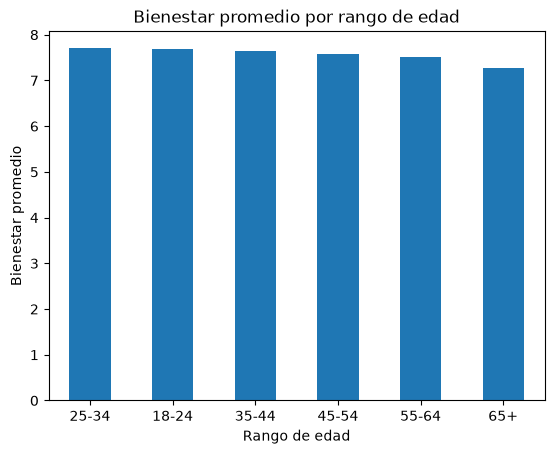

In [115]:
bienestar_por_edad.plot.bar()
plt.xlabel("Rango de edad")
plt.ylabel("Bienestar promedio")
plt.title("Bienestar promedio por rango de edad")
plt.xticks(rotation=0)
plt.show()

#### Calculamos la proporción de nacidos en Bogotá vs. fuera de Bogotá dentro de ese rango de edad.

In [116]:
df_rango = df_variables_filtrado.query("rango_edad == @rango_mayor_bienestar").copy()
df_rango["nacio_en_bogota"] = df_rango["P756"] == 1

proporcion = df_rango["nacio_en_bogota"].value_counts(normalize=True)*100
proporcion.rename({True: "Nacidos en Bogotá", False: "Nacidos fuera de Bogotá"})

nacio_en_bogota
Nacidos en Bogotá          63.157895
Nacidos fuera de Bogotá    36.842105
Name: proportion, dtype: float64

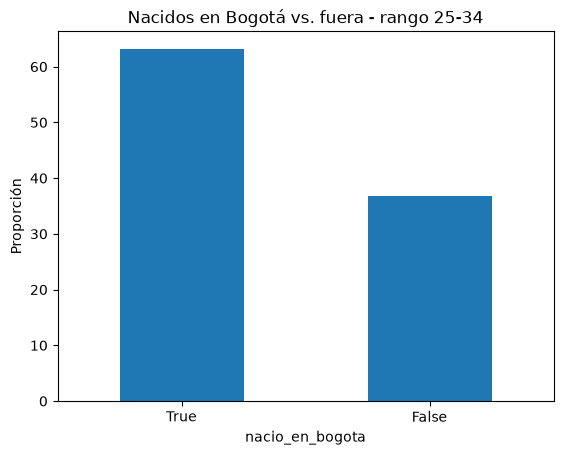

In [117]:
proporcion.plot.bar()
plt.ylabel("Proporción")
plt.title(f"Nacidos en Bogotá vs. fuera - rango {rango_mayor_bienestar}")
plt.xticks(rotation=0)
plt.show()
